# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Faqihuddin Al-Ghiffary
- Email: f4qihuddin@gmail.com
- Id Dicoding:faqihuddin_ag

# Persiapan

## Menyiapkan library yang dibutuhkan

Menginstall library tambahan yang dibutuhkan serta mengimport semua library yang akan digunakan pada proyek

In [1]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import kruskal
from scipy.stats import chi2_contingency
from sklearn.preprocessing import PowerTransformer
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.utils import resample
from sklearn.utils import shuffle
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical
from skopt.callbacks import VerboseCallback
import os
warnings.filterwarnings('ignore')

## Menyiapkan data yang akan digunakan

In [3]:
df = pd.read_csv(filepath_or_buffer='/content/drive/MyDrive/Dataset Submission Dicoding/data.csv', delimiter=';')

In [ ]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# Data Understanding

## Summary Statistics

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [ ]:
pd.set_option('display.max_columns', None)

df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


## Map Number to Label for Categorical Columns

In [ ]:
# Number to label mapping

marital_status_map = {
    1: 'single',
    2: 'married',
    3: 'widower',
    4: 'divorced',
    5: 'facto union',
    6: 'legally separated'
}

application_mode_map = {
    1: '1st phase - general contingent',
    2: 'Ordinance No. 612/93',
    5: '1st phase - special contingent (Azores Island)',
    7: 'Holders of other higher courses',
    10: 'Ordinance No. 854-B/99',
    15: 'International student (bachelor)',
    16: '1st phase - special contingent (Madeira Island)',
    17: '2nd phase - general contingent',
    18: '3rd phase - general contingent',
    26: ' Ordinance No. 533-A/99, item b2) (Different Plan)',
    27: 'Ordinance No. 533-A/99, item b3 (Other Institution)',
    39: 'Over 23 years old',
    42: 'Transfer',
    43: 'Change of course',
    44: 'Technological specialization diploma holders',
    51: 'Change of institution/course',
    53: 'Short cycle diploma holders',
    57: 'Change of institution/course (International)'
}

application_order_map = {
    0: 'first choice',
    1: 'second choice',
    2: 'third choice',
    3: 'fourth choice',
    4: 'fifth choice',
    5: 'sixth choice',
    6: 'seventh choice',
    9: 'last choice',
}

course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

daytime_evening_attendance_map = {
    1: 'daytime',
    0: 'evening'
}

previous_qualification = {
    1: 'Secondary education',
    2: "Higher education - bachelor's degree",
    3: 'Higher education - degree',
    4: "Higher education - master's",
    5: 'Higher education - doctorate',
    6: 'Frequency of higher education',
    9: '12th year of schooling - not completed',
    10: '11th year of schooling - not completed',
    12: 'Other - 11th year of schooling',
    14: '10th year of schooling',
    15: '10th year of schooling - not completed',
    19: 'Basic education 3rd cycle (9th/10th/11th year) or equiv.',
    38: 'Basic education 2nd cycle (6th/7th/8th year) or equiv.',
    39: 'Technological specialization course',
    40: 'Higher education - degree (1st cycle)',
    42: 'Professional higher technical course',
    43: 'Higher education - master (2nd cycle)'
}

nacionality_map = {
    1: 'Portuguese',
    2: 'German',
    6: 'Spanish',
    11: 'Italian',
    13: 'Ducth',
    14: 'English',
    17: 'Lithuanian',
    21: 'Angolan',
    22: 'Cape Verdean',
    24: 'Guinean',
    25: 'Mozambican',
    26: 'Santomean',
    32: 'Turkish',
    41: 'Brazilian',
    62: 'Romanian',
    100: 'Moldova (Republic of)',
    101: 'Mexican',
    103: 'Ukranian',
    105: 'Russian',
    108: 'Cuban',
    109: 'Colombian'
}

displaced_map = {
    0: 'no',
    1: 'yes'
}

educational_special_needs_map = {
    0: 'no',
    1: 'yes'
}

debtor_map = {
    0: 'no',
    1: 'yes'
}

tuition_fees_map = {
    0: 'no',
    1: 'yes'
}

gender_map = {
    0: 'female',
    1: 'male'
}

scholarship_map = {
    0: 'no',
    1: 'yes'
}

international_map = {
    0: 'no',
    1: 'yes'
}

In [ ]:
df['Marital_status'] = df['Marital_status'].map(marital_status_map)
df['Application_mode'] = df['Application_mode'].map(application_mode_map)
df['Application_order'] = df['Application_order'].map(application_order_map)
df['Course'] = df['Course'].map(course_map)
df['Daytime_evening_attendance'] = df['Daytime_evening_attendance'].map(daytime_evening_attendance_map)
df['Previous_qualification'] = df['Previous_qualification'].map(previous_qualification)
df['Nacionality'] = df['Nacionality'].map(nacionality_map)
df['Displaced'] = df['Displaced'].map(displaced_map)
df['Educational_special_needs'] = df['Educational_special_needs'].map(educational_special_needs_map)
df['Debtor'] = df['Debtor'].map(debtor_map)
df['Tuition_fees_up_to_date'] = df['Tuition_fees_up_to_date'].map(tuition_fees_map)
df['Gender'] = df['Gender'].map(gender_map)
df['Scholarship_holder'] = df['Scholarship_holder'].map(scholarship_map)
df['International'] = df['International'].map(international_map)

In [ ]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,single,2nd phase - general contingent,sixth choice,Animation and Multimedia Design,daytime,Secondary education,122.0,Portuguese,19,12,5,9,127.3,yes,no,no,yes,male,no,20,no,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,single,International student (bachelor),second choice,Tourism,daytime,Secondary education,160.0,Portuguese,1,3,3,3,142.5,yes,no,no,no,male,no,19,no,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,single,1st phase - general contingent,sixth choice,Communication Design,daytime,Secondary education,122.0,Portuguese,37,37,9,9,124.8,yes,no,no,no,male,no,19,no,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,single,2nd phase - general contingent,third choice,Journalism and Communication,daytime,Secondary education,122.0,Portuguese,38,37,5,3,119.6,yes,no,no,yes,female,no,20,no,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,married,Over 23 years old,second choice,Social Service (evening attendance),evening,Secondary education,100.0,Portuguese,37,38,9,9,141.5,no,no,no,yes,female,no,45,no,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Checking Missing Value

In [ ]:
df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


## Checking Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

## Features Distribution

### Numerical Features

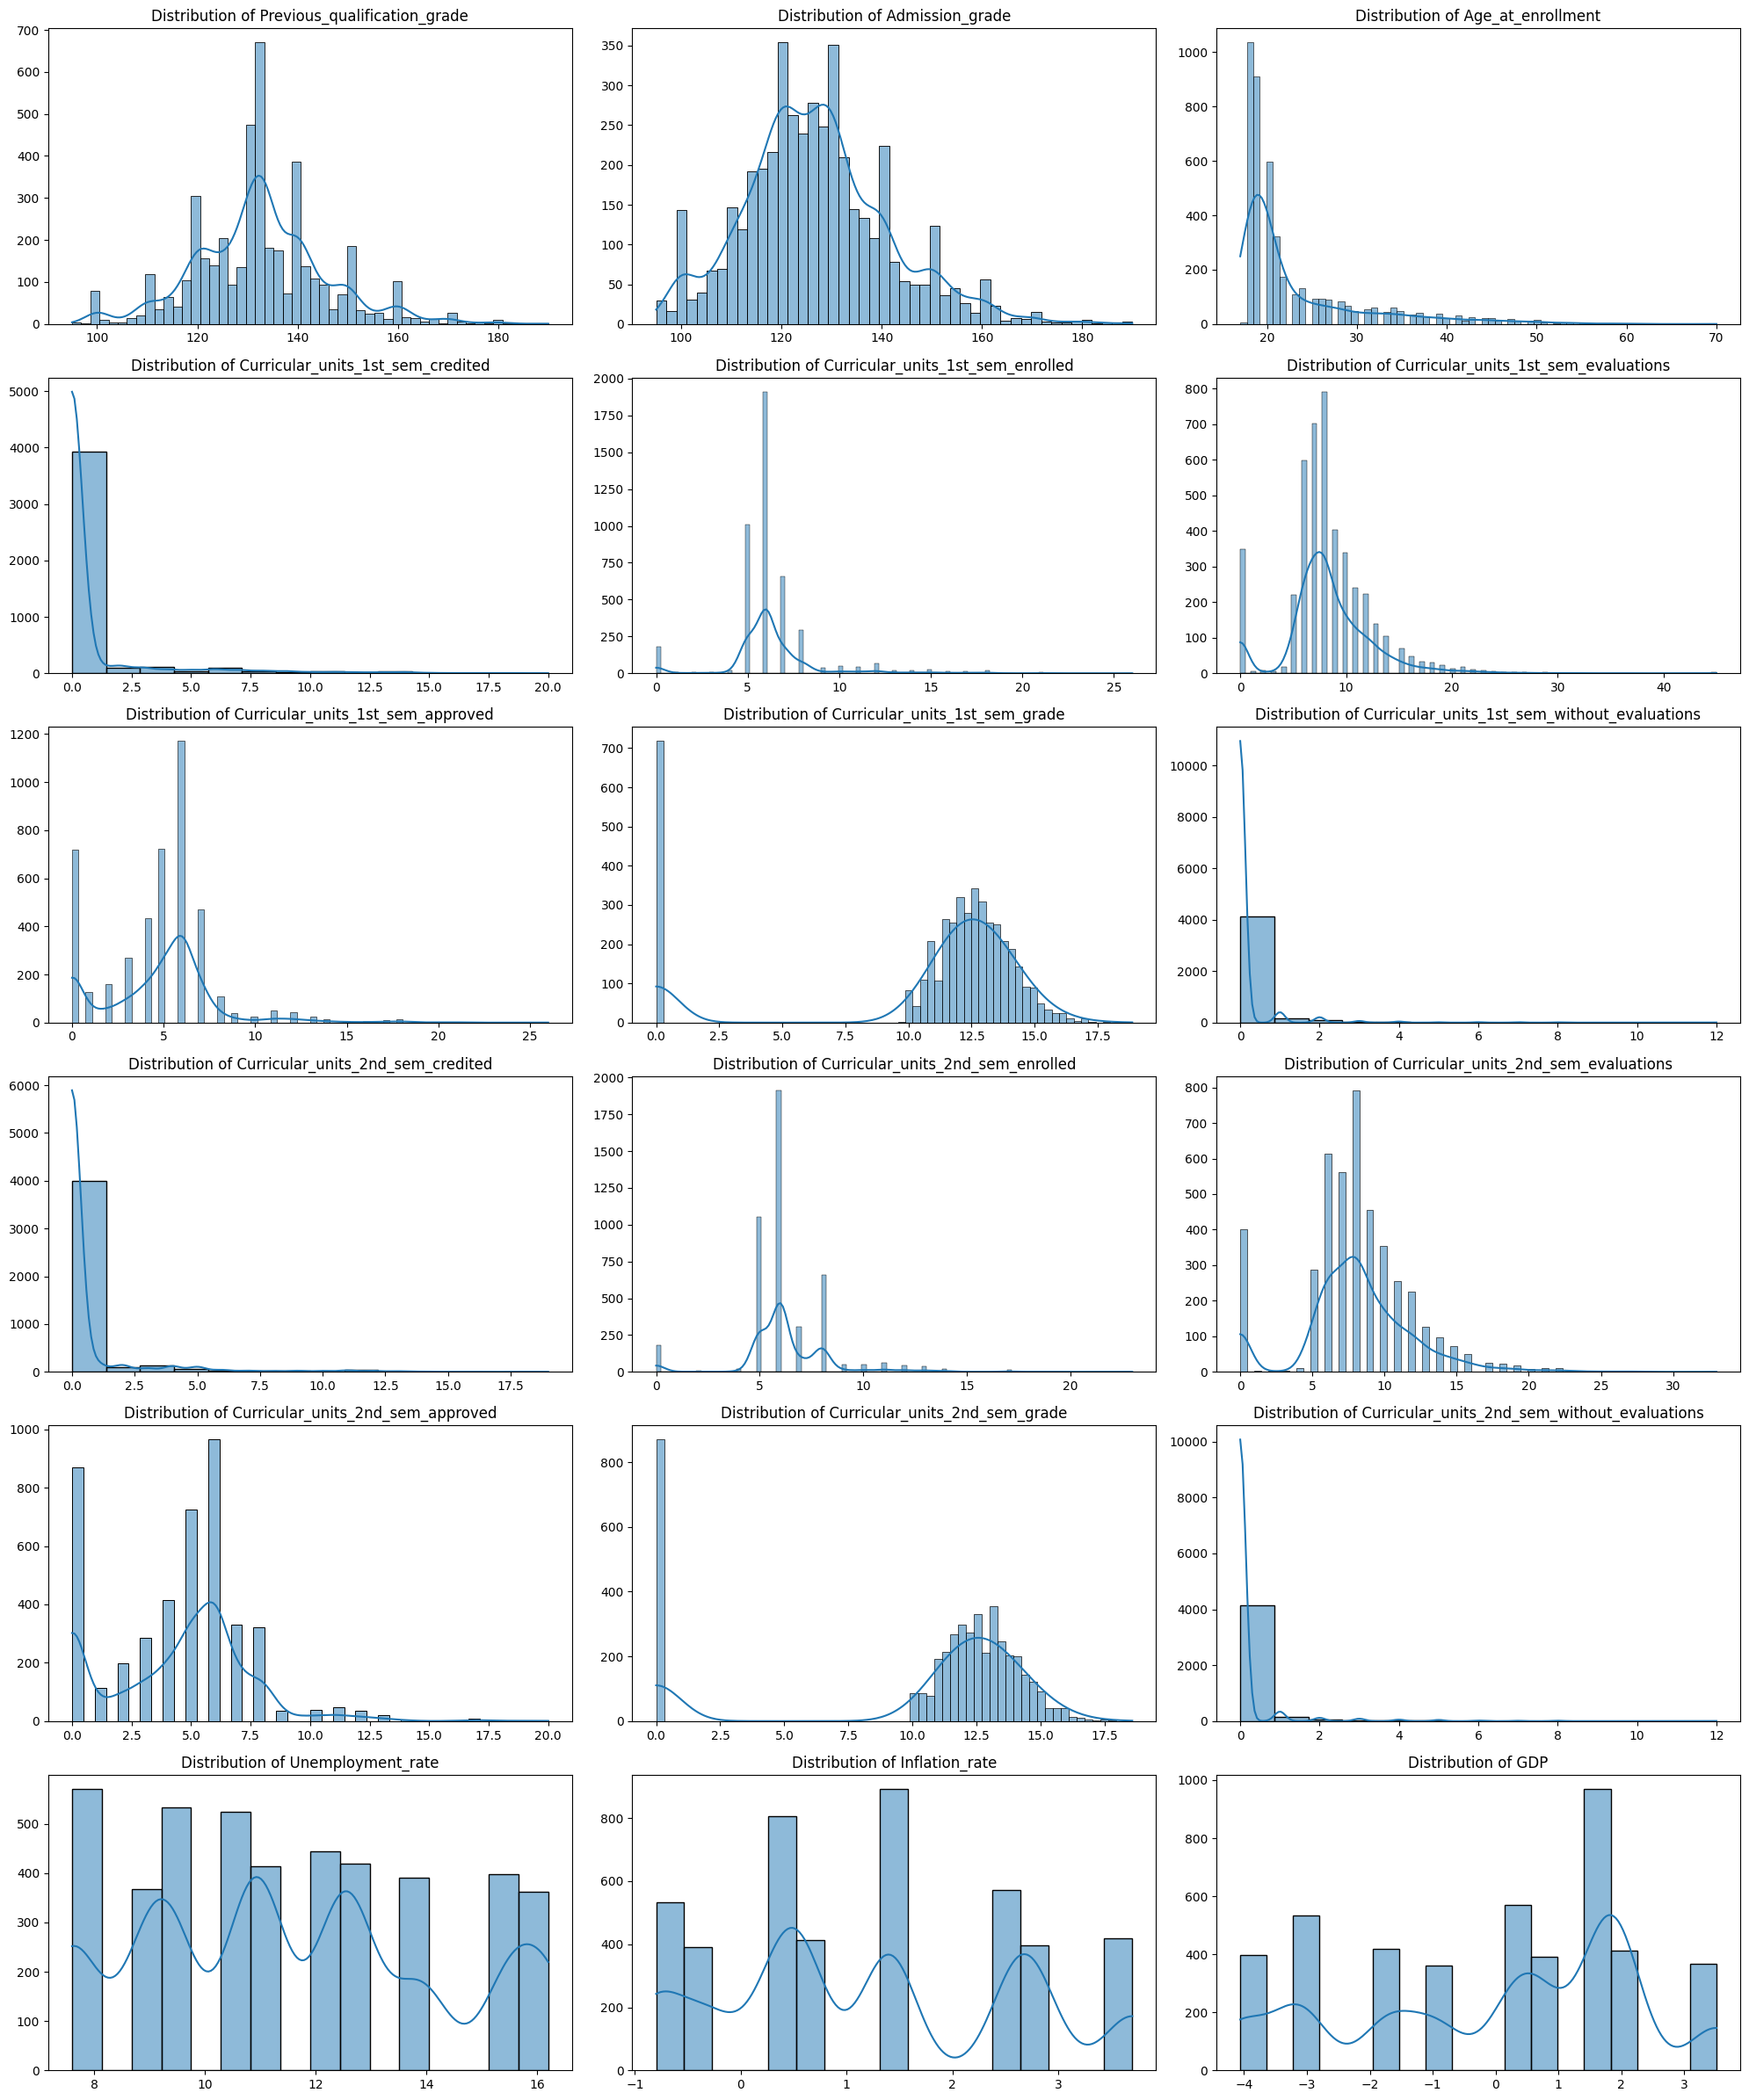

In [ ]:
# Menentukan kolom-kolom numerik
numerical_columns = df.drop(columns=['Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation'], errors='ignore').select_dtypes(include=['int64', 'float64']).columns

# Mengatur ukuran grid untuk subplot
num_cols = len(numerical_columns)
n_cols_plot = 3
n_rows_plot = (num_cols + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(nrows=n_rows_plot, ncols=n_cols_plot, figsize=(20, n_rows_plot * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Menghapus subplot kosong yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical Features

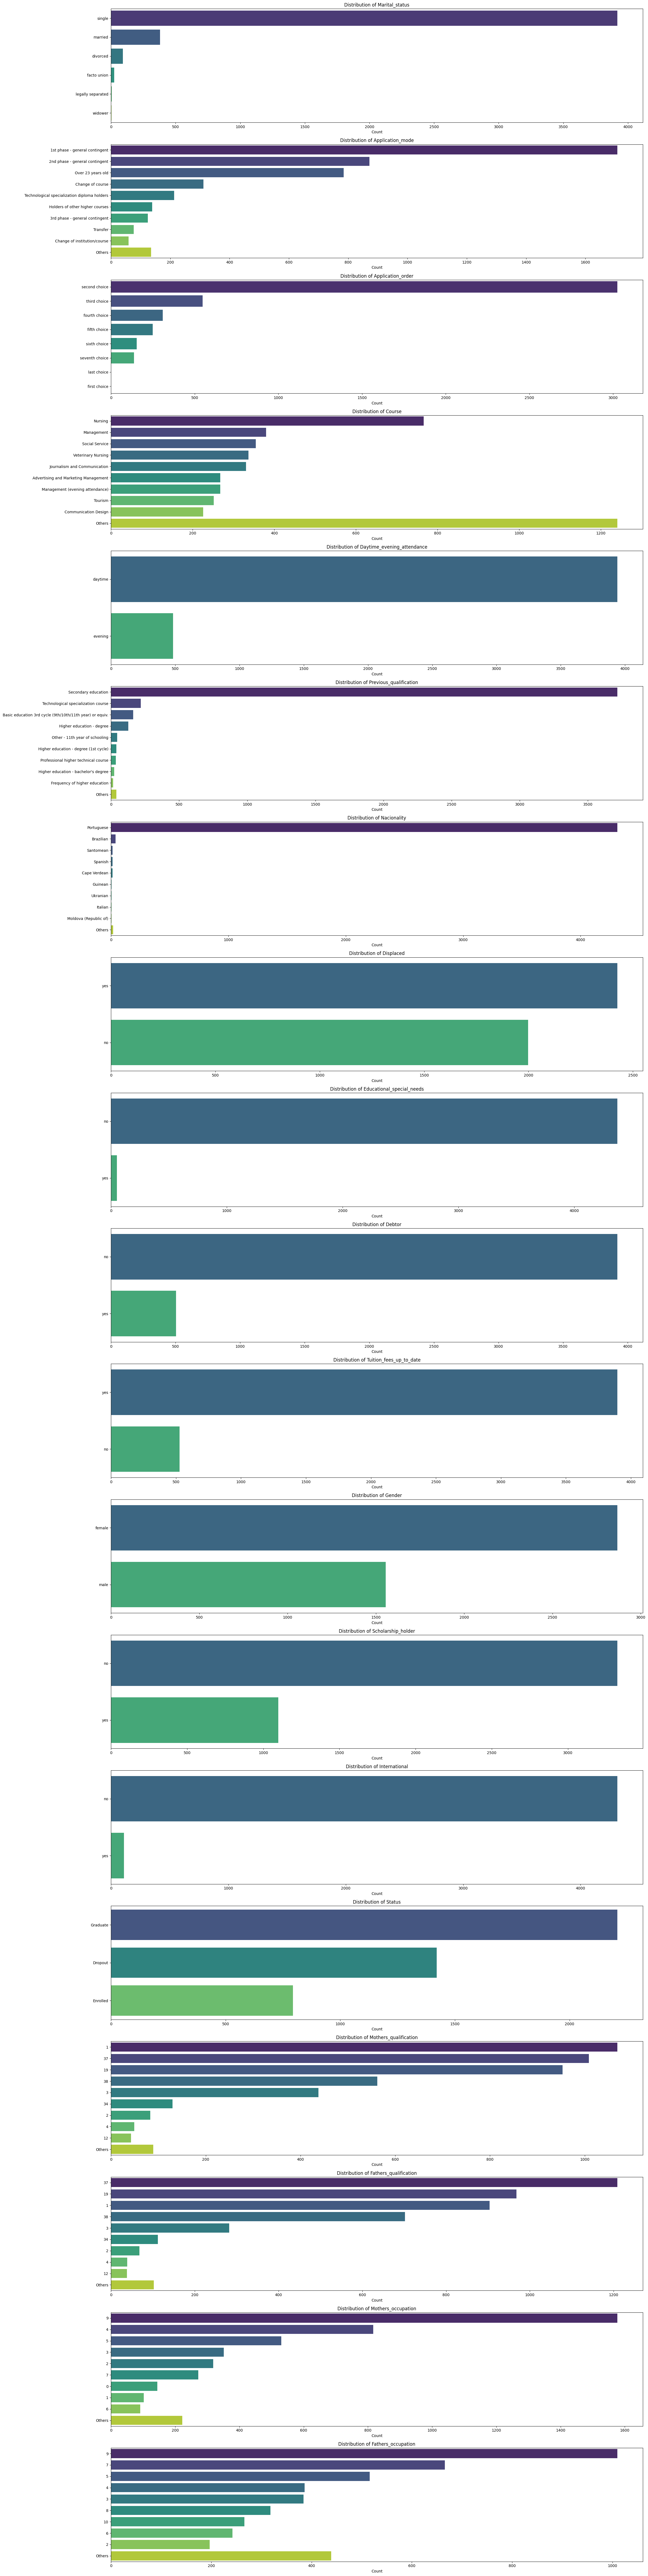

In [ ]:
# Mengambil kolom kategori awal (tipe object) dan mengubahnya menjadi list
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Menambahkan kolom-kolom kategori tambahan yang berupa angka
categorical_cols.extend(['Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation'])

# Mengatur ukuran grid untuk subplot
num_cols = len(categorical_cols)
n_cols_plot = 1
n_rows_plot = (num_cols + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(nrows=n_rows_plot, ncols=n_cols_plot, figsize=(24, n_rows_plot * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Mengambil value counts
    value_counts = df[col].value_counts()

    # Jika kategori unik lebih dari 10, kelompokkan sisanya menjadi 'Others'
    if len(value_counts) > 10:
        # Ambil 9 kategori teratas
        top_categories = value_counts.nlargest(9).index
        # Ganti kategori di luar top 9 menjadi 'Others'
        temp_series = df[col].apply(lambda x: x if x in top_categories else 'Others')
        # Mengambil urutan berdasarkan frekuensi 9 kategori teratas
        top_order = list(temp_series[temp_series != 'Others'].value_counts().index)
        # Menempatkan 'Others' di paling bawah (paling akhir dari list order)
        order = top_order + ['Others']
    else:
        temp_series = df[col]
        order = value_counts.index

    # Menggunakan y=col untuk mengubah barchart menjadi horizontal
    sns.countplot(y=temp_series, order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Menghapus subplot kosong yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Numerical Features Correlation

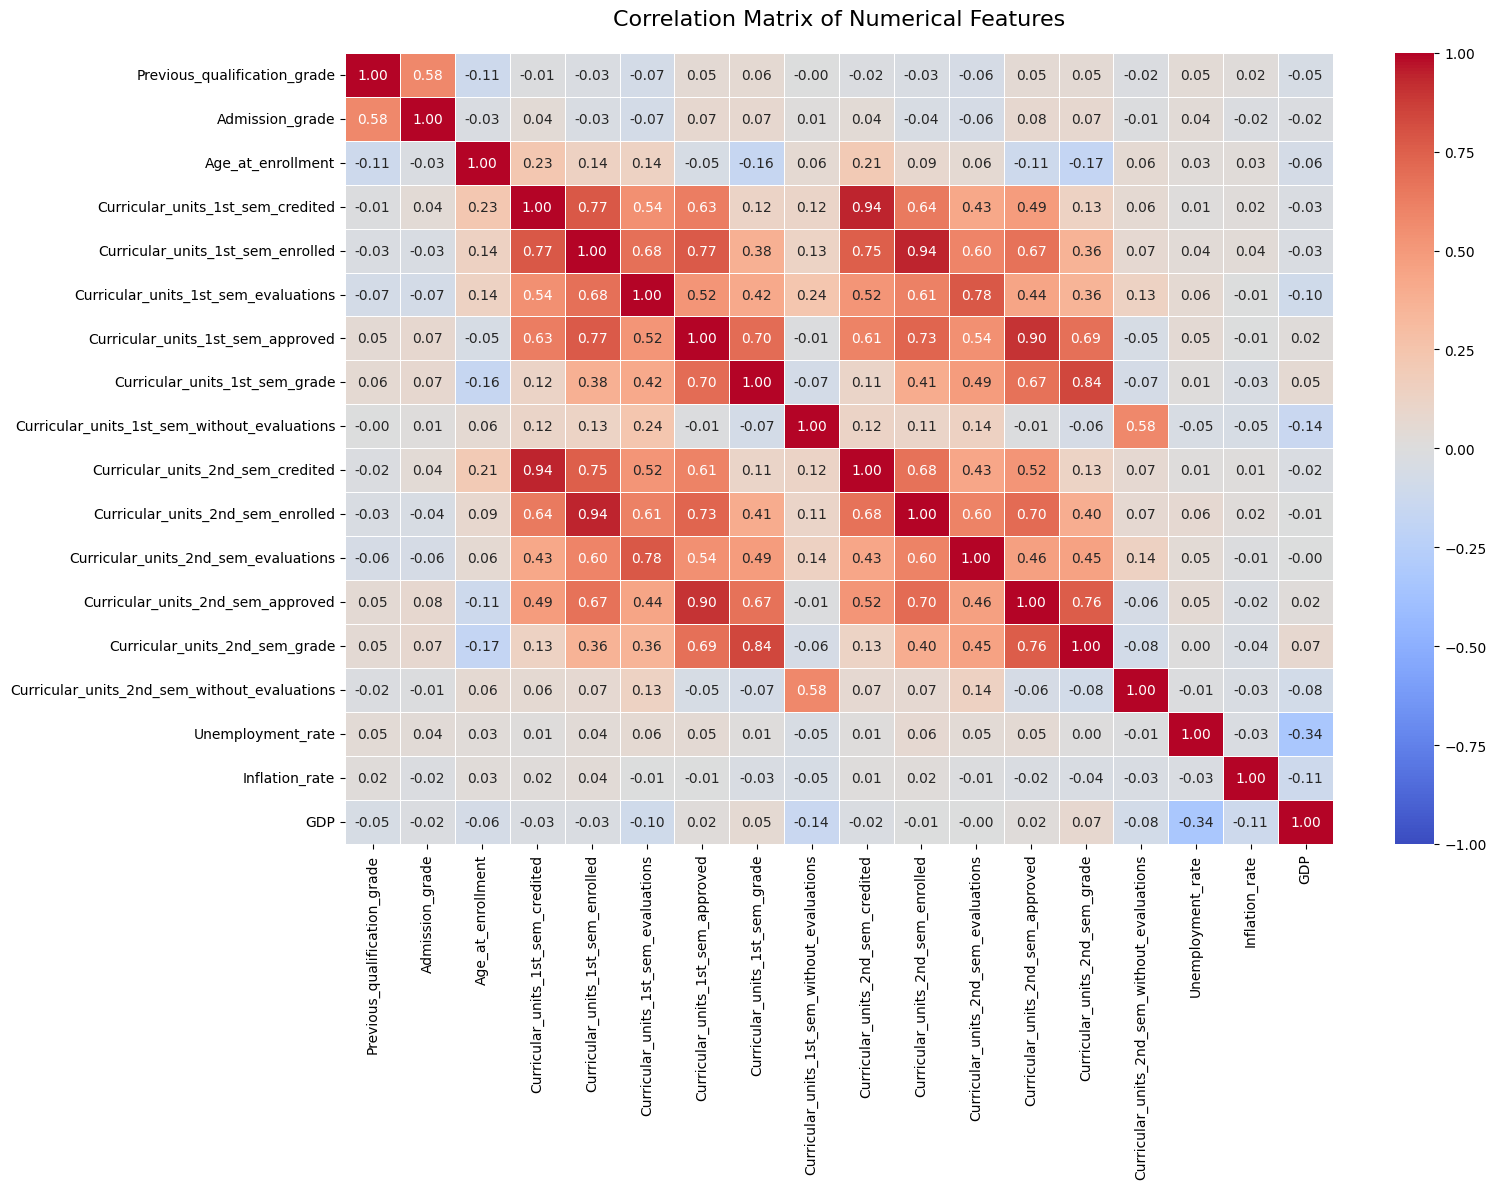

In [ ]:
# Memilih hanya kolom-kolom numerik dari dataframe
numerical_df = df.drop(columns=['Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation'], errors='ignore').select_dtypes(include=['int64', 'float64'])

# Menghitung matriks korelasi
correlation_matrix = numerical_df.corr()

# Mengatur ukuran gambar untuk heatmap
plt.figure(figsize=(16, 12))

# Membuat heatmap korelasi
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmax=1,
    vmin=-1,
    center=0
)

plt.title('Correlation Matrix of Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## Numerical Features and Target Correlation

In [ ]:
# Kruskal Wallis Test

kruskal_wallis_result = []

for col in numerical_columns:
  # Memisahkan data numerik berdasarkan 3 kategori di kolom 'Status'
  group_dropout = df[df['Status'] == 'Dropout'][col]
  group_graduate = df[df['Status'] == 'Graduate'][col]
  group_enrolled = df[df['Status'] == 'Enrolled'][col]

  # Melakukan Uji Kruskal-Wallis
  stat, p_value = kruskal(group_dropout, group_graduate, group_enrolled)

  kruskal_wallis_result.append({
      'Variable': col,
      'Statistik Uji': f'{stat:.4f}',
      'P-value': f'{p_value:.4e}',
      'significant': 'Yes' if p_value < 0.05 else 'No'
  })

num_corr_df = pd.DataFrame(kruskal_wallis_result).sort_values(by='P-value')
display(num_corr_df)

,Variable,Statistik Uji,P-value,significant
6,Curricular_units_1st_sem_approved,1561.7395,0.0000e+00,Yes
12,Curricular_units_2nd_sem_approved,1892.2765,0.0000e+00,Yes
13,Curricular_units_2nd_sem_grade,1390.7313,1.0151e-302,Yes
1,Admission_grade,73.2347,1.2511e-16,Yes
0,Previous_qualification_grade,63.6769,1.4884e-14,Yes
15,Unemployment_rate,12.8807,1.5959e-03,Yes
10,Curricular_units_2nd_sem_enrolled,270.7315,1.6270e-59,Yes
11,Curricular_units_2nd_sem_evaluations,182.9464,1.8780e-40,Yes
7,Curricular_units_1st_sem_grade,1094.1865,2.5143e-238,Yes
4,Curricular_units_1st_sem_enrolled,246.6171,2.8039e-54,Yes


## Categorical Features and Target Correlation

In [ ]:
# Chi-Square Test

chi2_results = []

for col in categorical_cols:
    if col != 'Status':
      # Membuat tabel kontingensi
      contingency_table = pd.crosstab(df[col], df['Status'])

      # Melakukan uji Chi-Square
      chi2, p, dof, ex = chi2_contingency(contingency_table)
      chi2_results.append({'Variable': col, 'P-value': p, 'Significant': 'Yes' if p < 0.05 else 'No'})

# Menampilkan hasil signifikansi
chi2_df = pd.DataFrame(chi2_results).sort_values(by='P-value')
display(chi2_df)

,Variable,P-value,Significant
10,Tuition_fees_up_to_date,1.471628e-179,Yes
3,Course,2.316571e-97,Yes
12,Scholarship_holder,9.593930e-90,Yes
1,Application_mode,1.964657e-77,Yes
9,Debtor,4.858552e-57,Yes
11,Gender,2.222480e-51,Yes
16,Mothers_occupation,1.630859e-31,Yes
5,Previous_qualification,7.160305e-30,Yes
14,Mothers_qualification,5.823844e-21,Yes
15,Fathers_qualification,3.175007e-19,Yes


## Chekcing Outliers

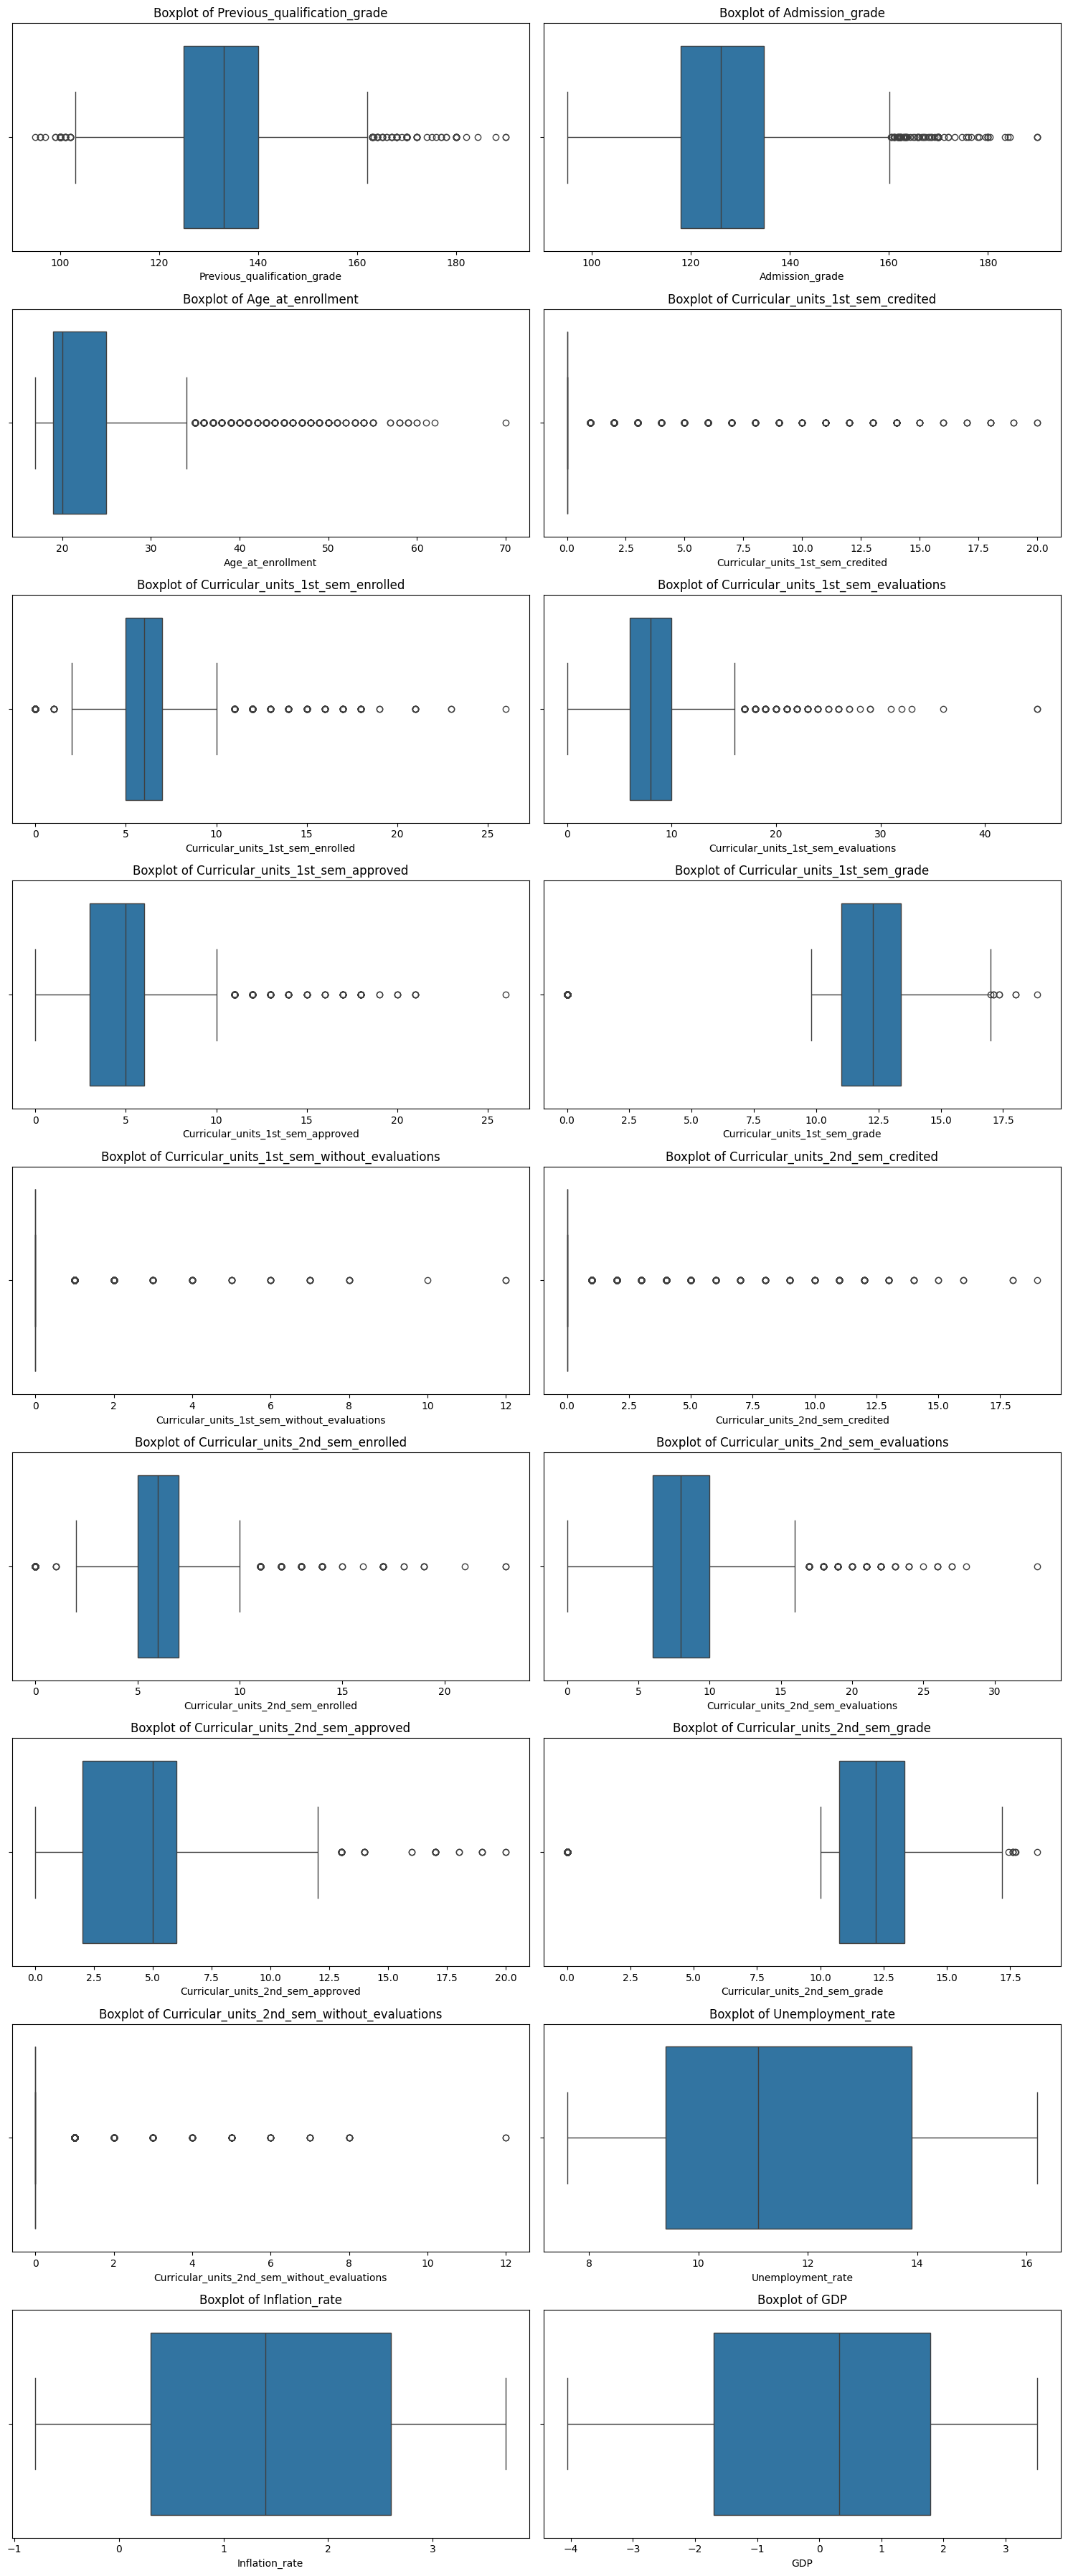

In [ ]:
n_cols = 2
n_rows = (len(numerical_columns) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()  # Mengubah array 2D axes menjadi 1D agar mudah diiterasi

for idx, col in enumerate(numerical_columns):
    sns.boxplot(data=df, x=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')

# Menghapus/menyembunyikan subplot yang tidak terpakai
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Answering Business Problem Statement

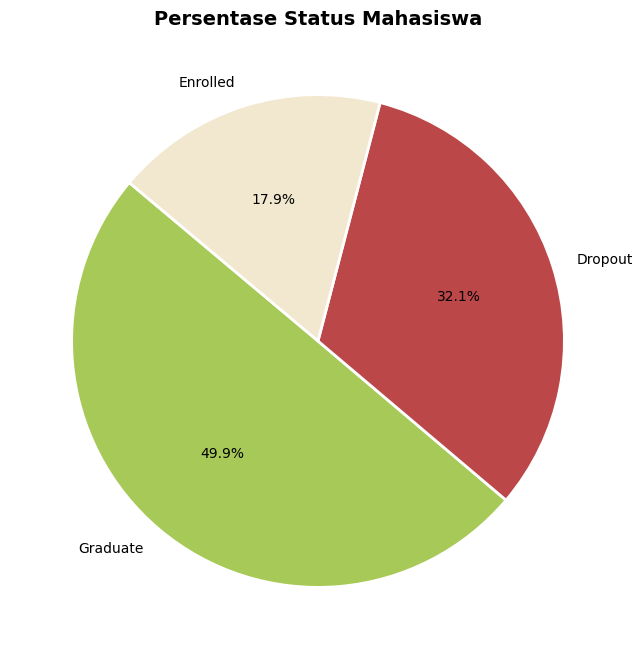

In [ ]:
# Menghitung frekuensi setiap kategori pada kolom 'Status'
status_counts = df['Status'].value_counts()

my_colors = ['#a7c957', '#bc4749', '#f2e8cf']
custom_palette = sns.color_palette(my_colors)

# Membuat figure
plt.figure(figsize=(8, 8))

# Membuat pie chart menggunakan matplotlib
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=custom_palette,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Persentase Status Mahasiswa', fontsize=14, fontweight='bold')
plt.show()

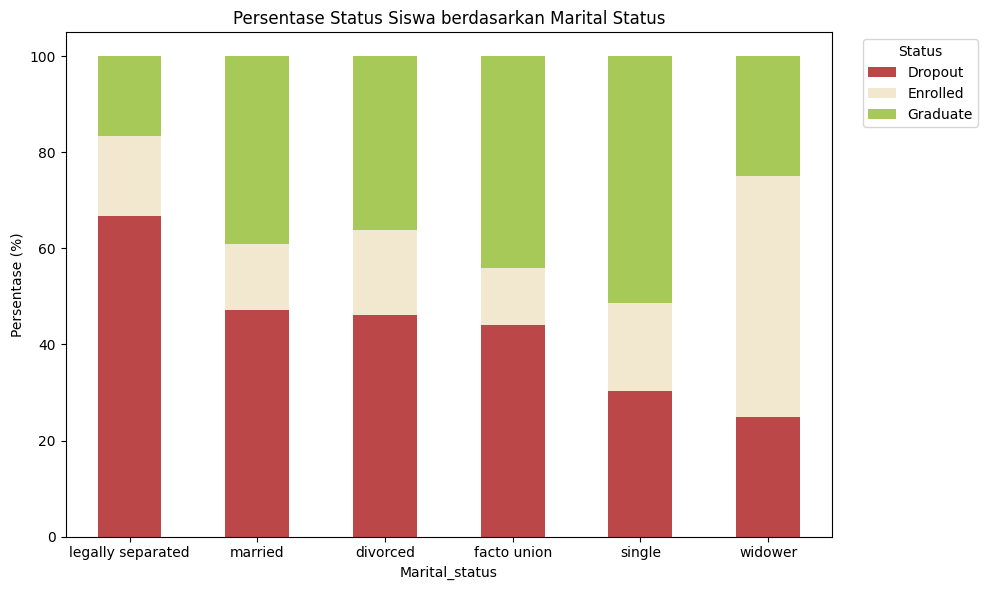

In [ ]:
marital_prop = df.groupby('Marital_status')['Status'].value_counts(normalize=True).unstack() * 100
marital_prop = marital_prop.sort_values(by='Dropout', ascending=False)

# Visualisasi Stacked Bar Chart untuk Proporsi
marital_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Marital Status')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

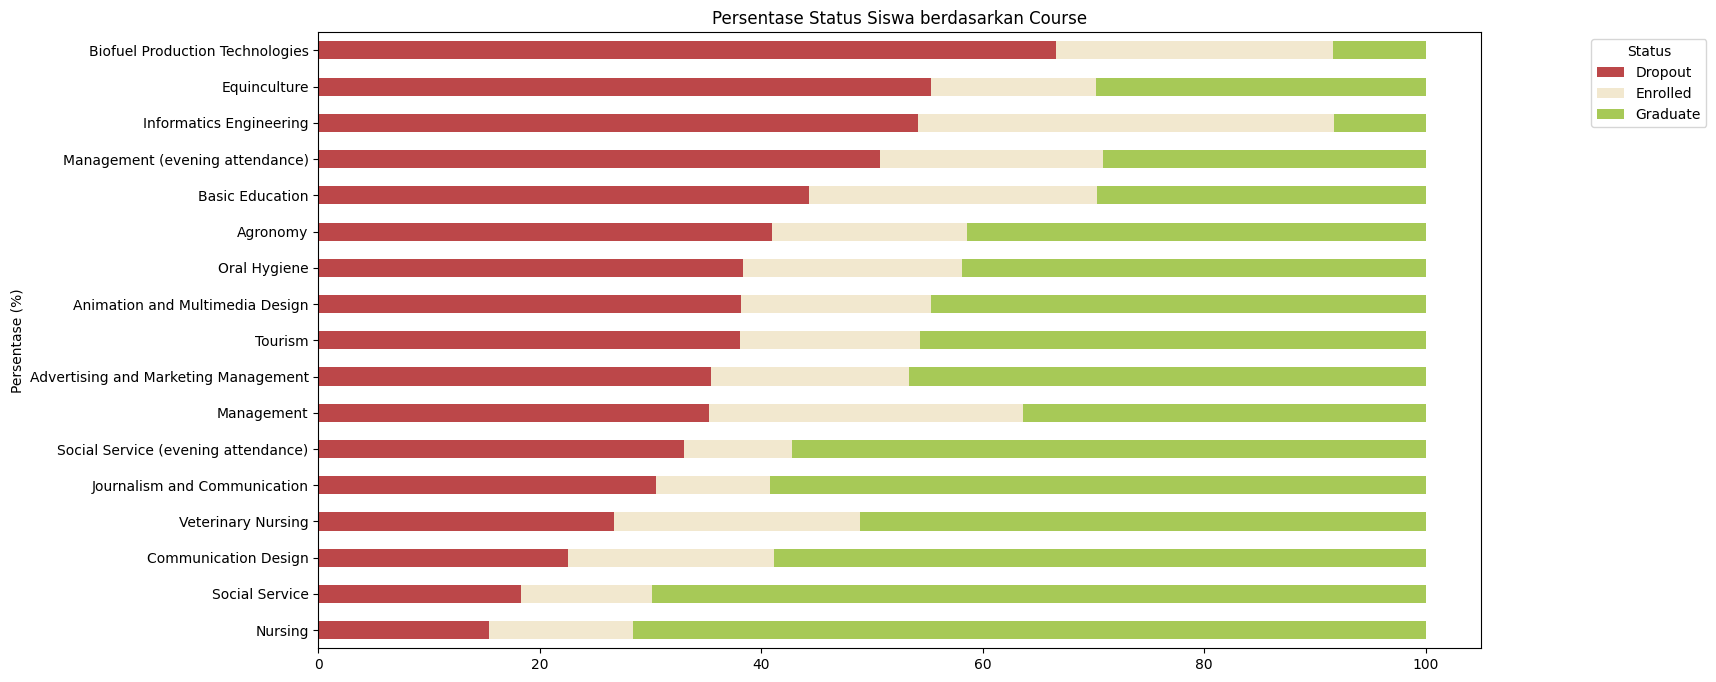

In [ ]:
course_prop = df.groupby('Course')['Status'].value_counts(normalize=True).unstack() * 100
course_prop = course_prop.sort_values(by='Dropout', ascending=True)

# Visualisasi Stacked Bar Chart untuk Proporsi
course_prop.plot(kind='barh', stacked=True, figsize=(15, 8), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Course')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.show()

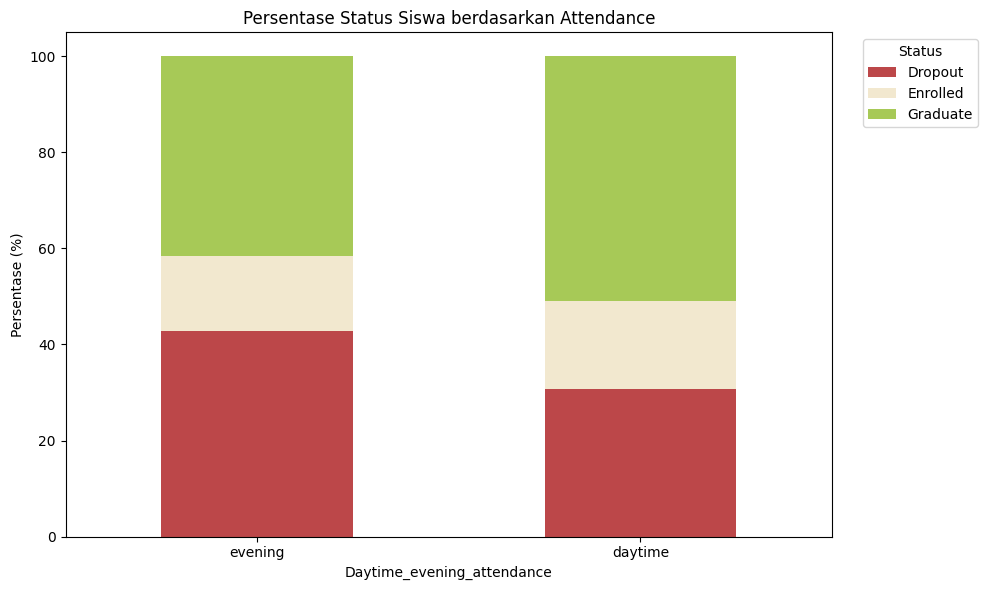

In [ ]:
attendance_prop = df.groupby('Daytime_evening_attendance')['Status'].value_counts(normalize=True).unstack() * 100
attendance_prop = attendance_prop.sort_values(by='Dropout', ascending=False)

# Visualisasi Stacked Bar Chart untuk Proporsi
attendance_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Attendance')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

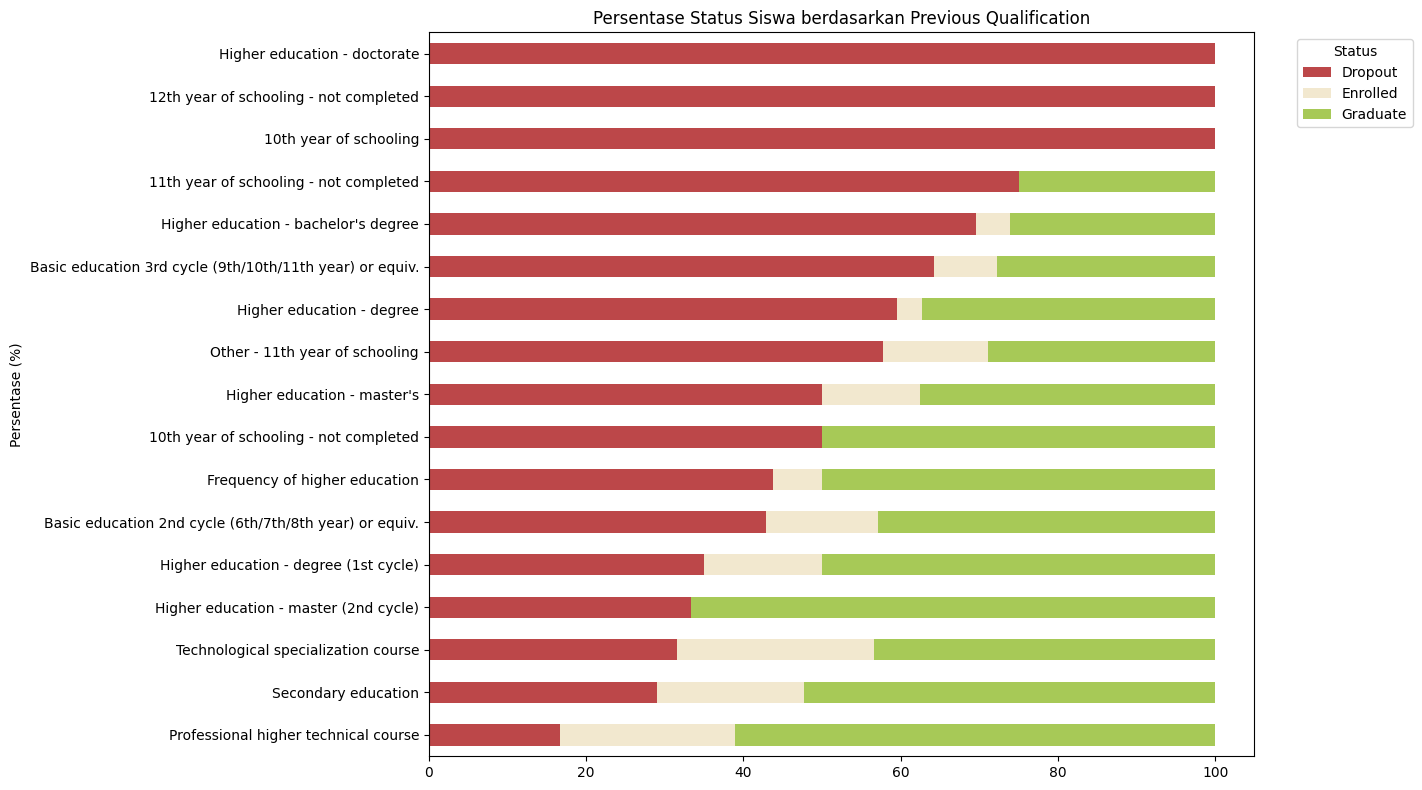

In [ ]:
attendance_prop = df.groupby('Previous_qualification')['Status'].value_counts(normalize=True).unstack() * 100
attendance_prop = attendance_prop.sort_values(by='Dropout', ascending=True)

# Visualisasi Stacked Bar Chart untuk Proporsi
attendance_prop.plot(kind='barh', stacked=True, figsize=(15, 8), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Previous Qualification')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
def age_to_category(age):
    if age >= 17 and age <= 19:
        return 'Young'
    elif age >= 20 and age <= 25:
        return 'Early Adult'
    elif age >= 26 and age <= 35:
        return 'Adult'
    elif age >= 36 and age <= 45:
        return 'Middle-Aged'
    else:
        return 'Old'

age_df = df.copy()

age_df['Age_at_enrollment'] = age_df['Age_at_enrollment'].apply(age_to_category)
age_df['Age_at_enrollment'].value_counts()

,count
Age_at_enrollment,
Young,1952
Early Adult,1427
Adult,653
Middle-Aged,279
Old,113


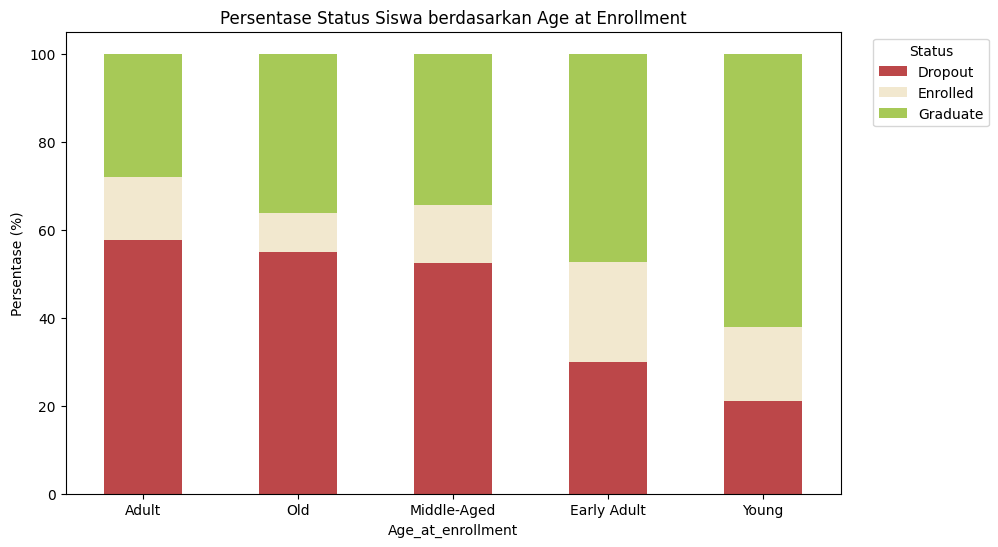

In [6]:
age_prop = age_df.groupby('Age_at_enrollment')['Status'].value_counts(normalize=True).unstack() * 100
age_prop = age_prop.sort_values(by='Dropout', ascending=False)

# Visualisasi Stacked Bar Chart untuk Proporsi
age_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Age at Enrollment')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.show()

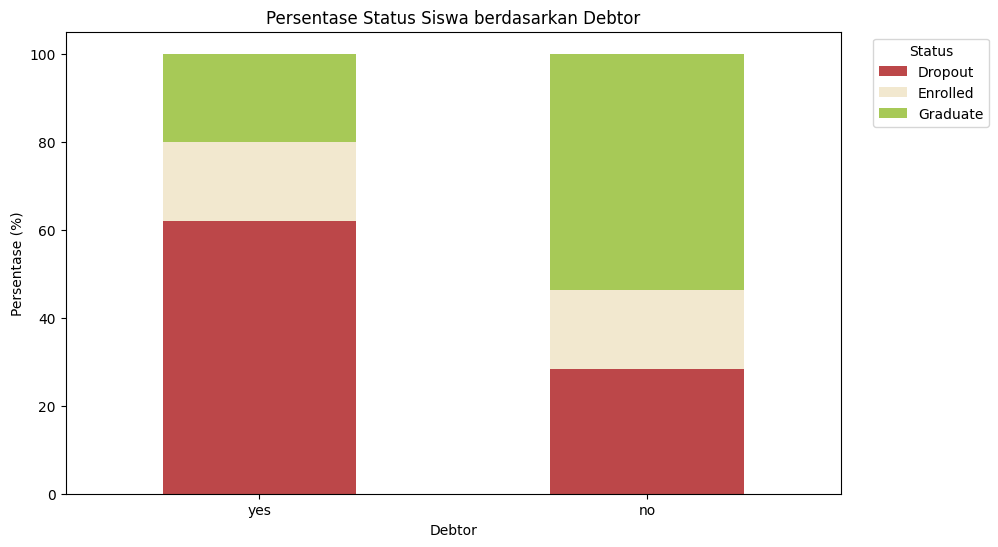

In [ ]:
debtor_prop = age_df.groupby('Debtor')['Status'].value_counts(normalize=True).unstack() * 100
debtor_prop = debtor_prop.sort_values(by='Dropout', ascending=False)

# Visualisasi Stacked Bar Chart untuk Proporsi
debtor_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Debtor')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.show()

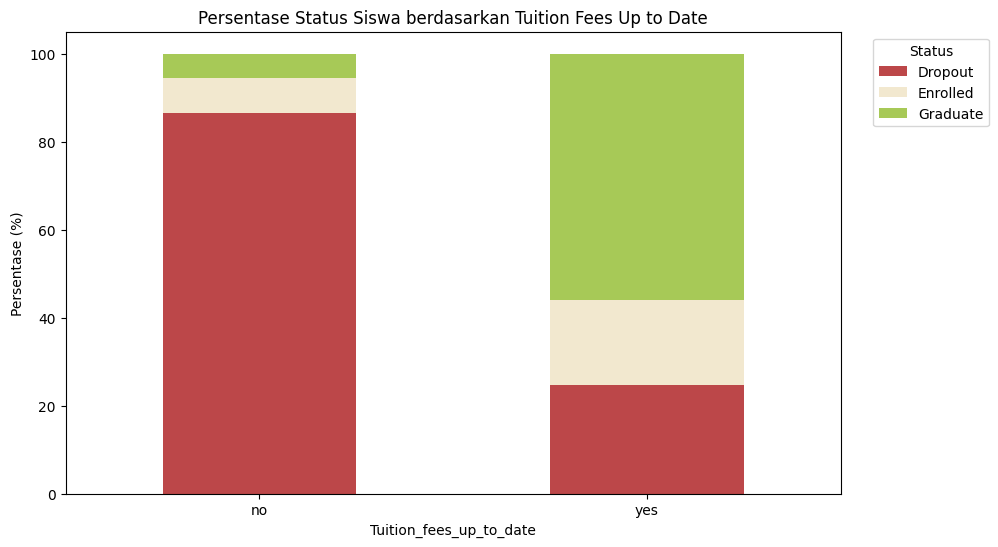

In [ ]:
tuition_fees_prop = age_df.groupby('Tuition_fees_up_to_date')['Status'].value_counts(normalize=True).unstack() * 100
tuition_fees_prop = tuition_fees_prop.sort_values(by='Dropout', ascending=False)

# Visualisasi Stacked Bar Chart untuk Proporsi
tuition_fees_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Tuition Fees Up to Date')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.show()

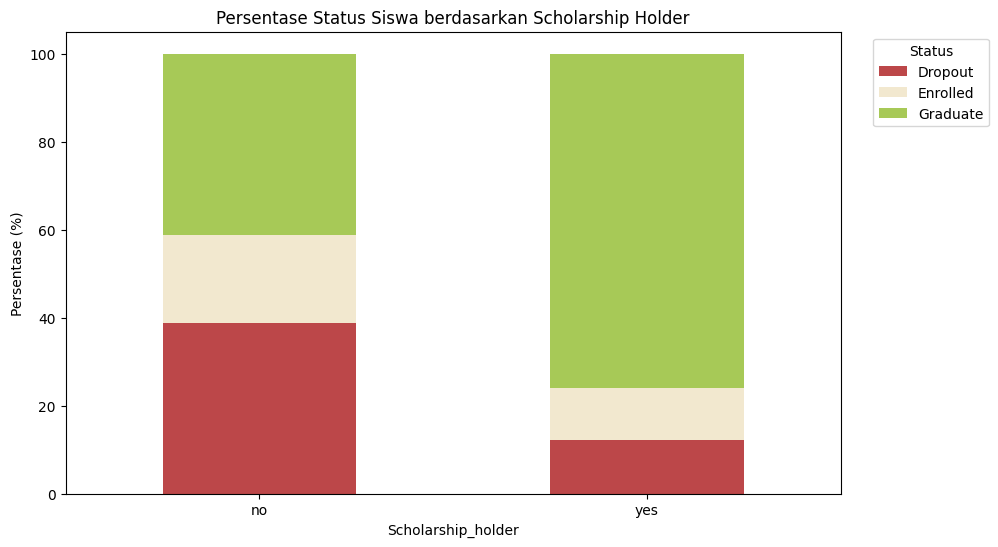

In [ ]:
scholarship_holder_prop = age_df.groupby('Scholarship_holder')['Status'].value_counts(normalize=True).unstack() * 100
scholarship_holder_prop = scholarship_holder_prop.sort_values(by='Dropout', ascending=False)

# Visualisasi Stacked Bar Chart untuk Proporsi
scholarship_holder_prop.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#bc4749', '#f2e8cf', '#a7c957'])
plt.title('Persentase Status Siswa berdasarkan Scholarship Holder')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.xticks(rotation=0)
plt.show()

# Data Preparation / Preprocessing

## Feature Selection

In [ ]:
selected_cols =[
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_enrolled', 'Age_at_enrollment',
    'Curricular_units_1st_sem_evaluations', 'Tuition_fees_up_to_date', 'Course', 'Scholarship_holder', 'Application_mode', 'Debtor', 'Status'
]

df = df[selected_cols]
df.head()

,Curricular_units_1st_sem_approved,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_enrolled,Age_at_enrollment,Curricular_units_1st_sem_evaluations,Tuition_fees_up_to_date,Course,Scholarship_holder,Application_mode,Debtor,Status
0,0,0,0.000000,0,0,0.000000,0,20,0,yes,Animation and Multimedia Design,no,2nd phase - general contingent,no,Dropout
1,6,6,13.666667,6,6,14.000000,6,19,6,no,Tourism,no,International student (bachelor),no,Graduate
2,0,0,0.000000,6,0,0.000000,6,19,0,no,Communication Design,no,1st phase - general contingent,no,Dropout
3,6,5,12.400000,6,10,13.428571,6,20,8,yes,Journalism and Communication,no,2nd phase - general contingent,no,Graduate
4,5,6,13.000000,6,6,12.333333,6,45,9,yes,Social Service (evening attendance),no,Over 23 years old,no,Graduate


## Power Transform

In [ ]:
def power_transforms(features, df):
  df = df[features]
  for feature in features:
    transformer = PowerTransformer(standardize=True)
    y = np.asanyarray(df[feature])
    y = y.reshape(-1,1)
    transformer.fit(y)
    df["transform_{}".format(feature)] = transformer.transform(y)
    df.drop([feature], axis=1, inplace=True)
    joblib.dump(transformer, "transformers/transformer_{}.joblib".format(feature))
  return df

In [ ]:
numerical_columns = [
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_enrolled', 'Age_at_enrollment',
    'Curricular_units_1st_sem_evaluations'
]

In [ ]:
os.makedirs("transformers", exist_ok=True)

transformed_df = power_transforms(numerical_columns, df)
transformed_df.head()

,transform_Curricular_units_1st_sem_approved,transform_Curricular_units_2nd_sem_approved,transform_Curricular_units_2nd_sem_grade,transform_Curricular_units_2nd_sem_enrolled,transform_Curricular_units_2nd_sem_evaluations,transform_Curricular_units_1st_sem_grade,transform_Curricular_units_1st_sem_enrolled,transform_Age_at_enrollment,transform_Curricular_units_1st_sem_evaluations
0,-1.712471,-1.591908,-1.902454,-2.939873,-2.140754,-2.074367,-2.997413,-0.226299,-2.254687
1,0.484731,0.565695,0.712547,-0.095537,-0.498405,0.823763,-0.065206,-0.635746,-0.504255
2,-1.712471,-1.591908,-1.902454,-0.095537,-2.140754,-2.074367,-0.065206,-0.635746,-2.254687
3,0.484731,0.263542,0.365457,-0.095537,0.503847,0.626468,-0.065206,-0.226299,-0.017067
4,0.184843,0.565695,0.527718,-0.095537,-0.498405,0.265583,-0.065206,1.799943,0.217520


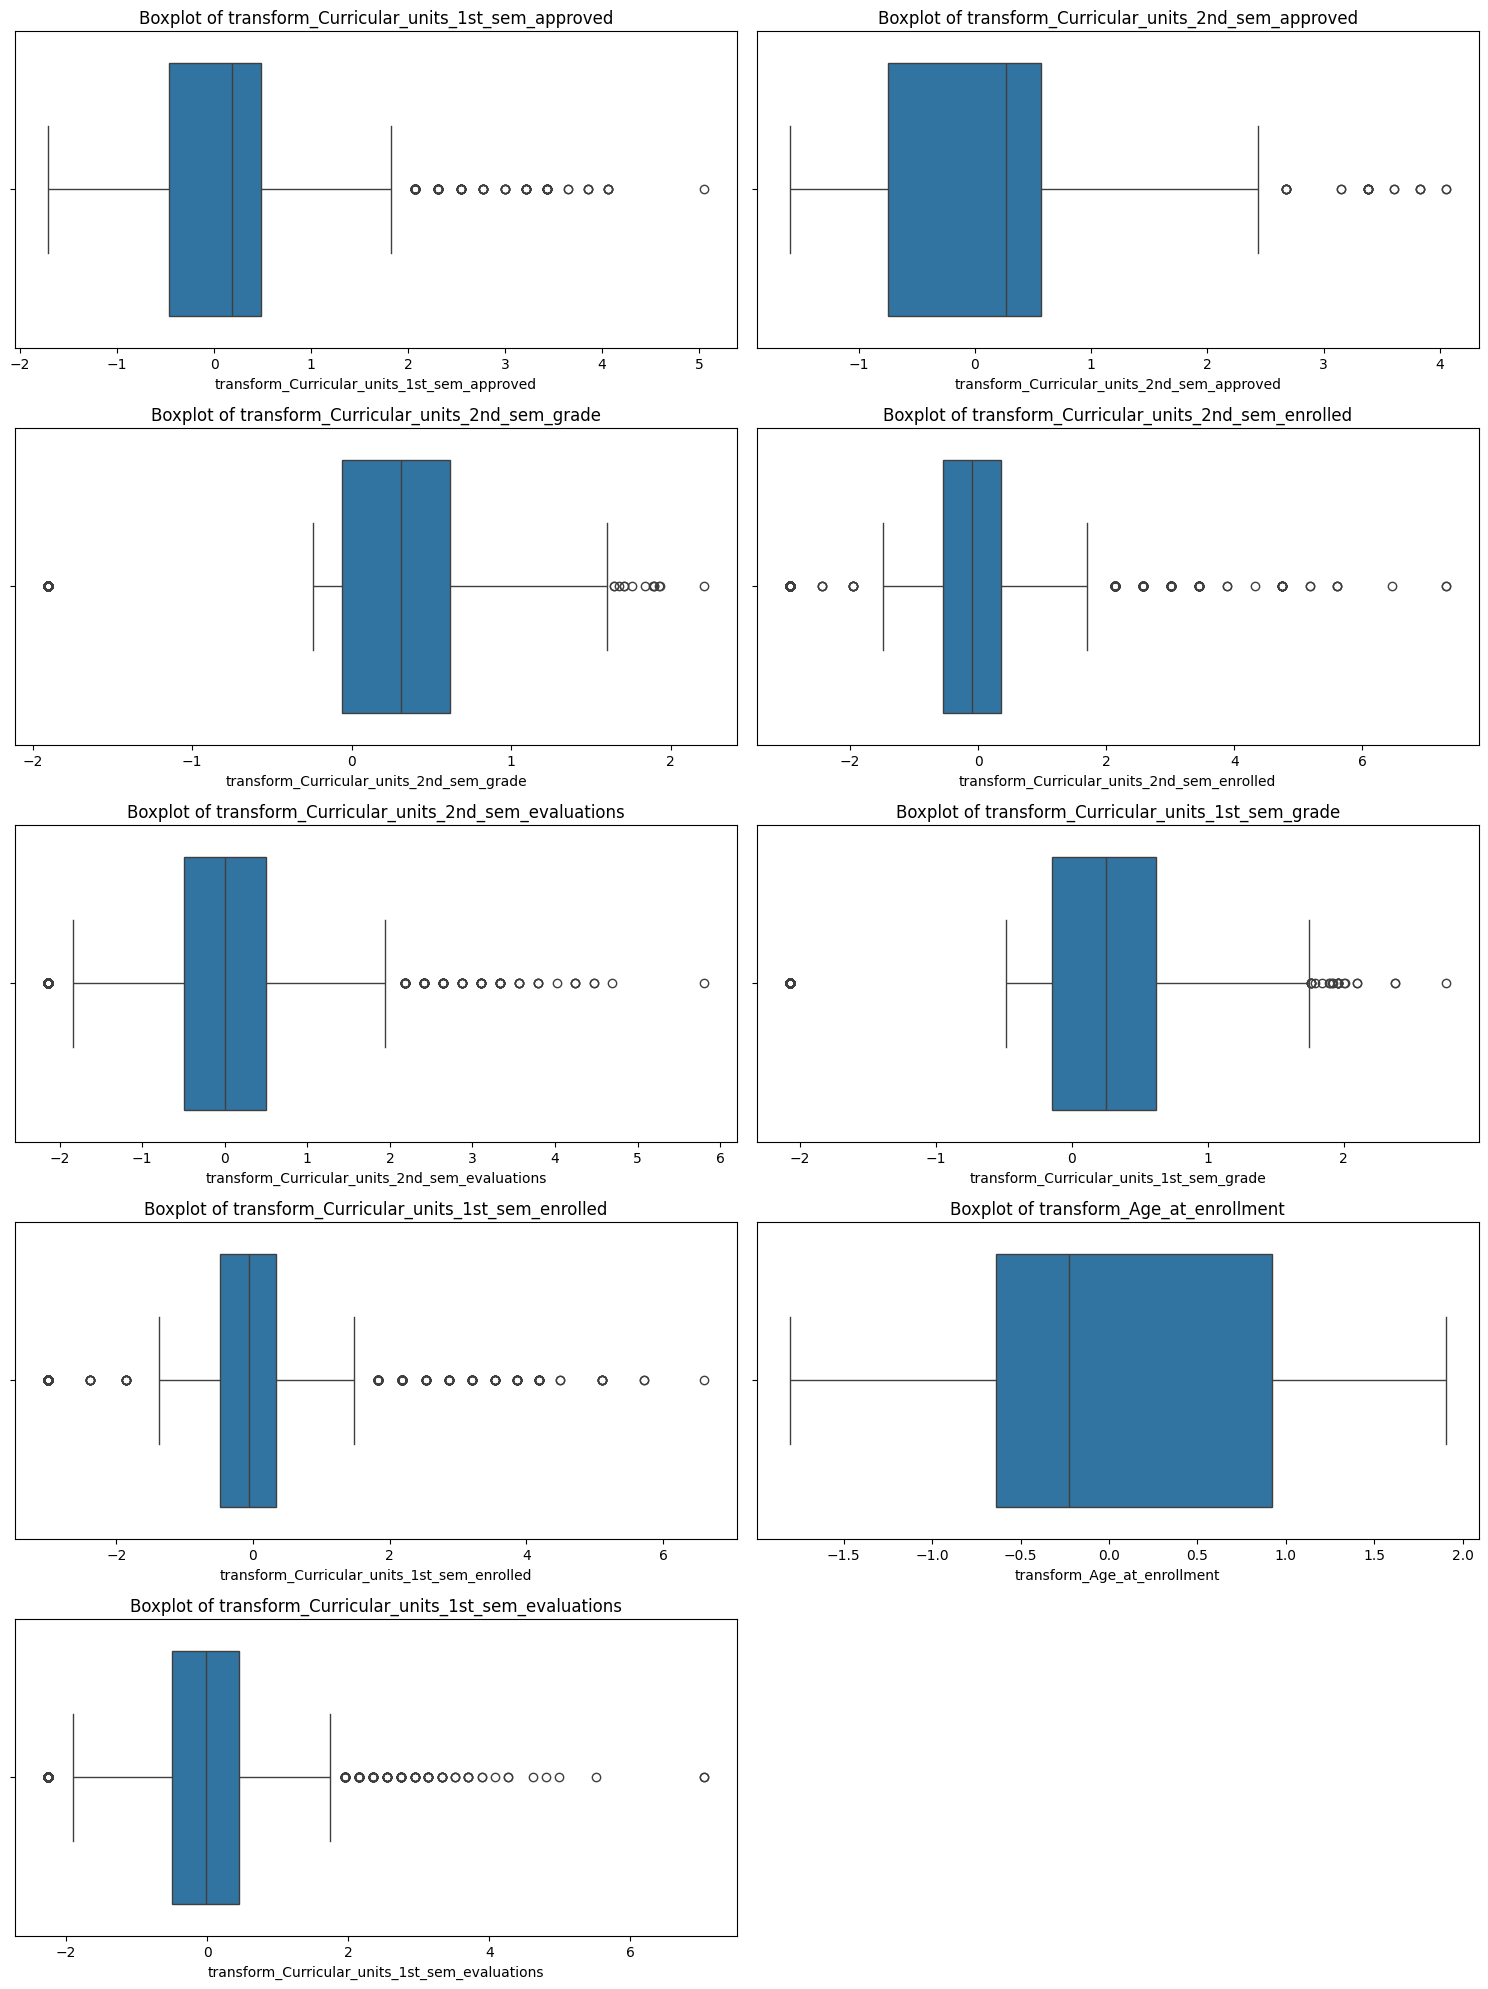

In [ ]:
cols_to_plot = [c for c in transformed_df.columns]
n_cols = 2
n_rows = (len(cols_to_plot) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()  # Mengubah array 2D axes menjadi 1D agar mudah diiterasi

for idx, col in enumerate(cols_to_plot):
    sns.boxplot(data=transformed_df, x=col, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')

# Menghapus/menyembunyikan subplot yang tidak terpakai
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Menghapus kolom asli yang sudah ditransformasi dari selected_df
df = df.drop(numerical_columns, axis=1)

selected_df_filtered = df.loc[transformed_df.index]

# Gabungkan data yang sudah sinkron
merged_df = pd.concat([selected_df_filtered, transformed_df], axis=1)

print("Ukuran data setelah sinkronisasi dan penggabungan:", merged_df.shape)
display(merged_df.head())

Ukuran data setelah sinkronisasi dan penggabungan: (4424, 15)


,Tuition_fees_up_to_date,Course,Scholarship_holder,Application_mode,Debtor,Status,transform_Curricular_units_1st_sem_approved,transform_Curricular_units_2nd_sem_approved,transform_Curricular_units_2nd_sem_grade,transform_Curricular_units_2nd_sem_enrolled,transform_Curricular_units_2nd_sem_evaluations,transform_Curricular_units_1st_sem_grade,transform_Curricular_units_1st_sem_enrolled,transform_Age_at_enrollment,transform_Curricular_units_1st_sem_evaluations
0,yes,Animation and Multimedia Design,no,2nd phase - general contingent,no,Dropout,-1.712471,-1.591908,-1.902454,-2.939873,-2.140754,-2.074367,-2.997413,-0.226299,-2.254687
1,no,Tourism,no,International student (bachelor),no,Graduate,0.484731,0.565695,0.712547,-0.095537,-0.498405,0.823763,-0.065206,-0.635746,-0.504255
2,no,Communication Design,no,1st phase - general contingent,no,Dropout,-1.712471,-1.591908,-1.902454,-0.095537,-2.140754,-2.074367,-0.065206,-0.635746,-2.254687
3,yes,Journalism and Communication,no,2nd phase - general contingent,no,Graduate,0.484731,0.263542,0.365457,-0.095537,0.503847,0.626468,-0.065206,-0.226299,-0.017067
4,yes,Social Service (evening attendance),no,Over 23 years old,no,Graduate,0.184843,0.565695,0.527718,-0.095537,-0.498405,0.265583,-0.065206,1.799943,0.217520


In [ ]:
numerical_columns = [f'transform_{col}' for col in numerical_columns]

## Train-Test-Split

In [ ]:
train_df, test_df = train_test_split(merged_df, test_size=0.2, random_state=42)

In [ ]:
print(train_df.shape)
print(test_df.shape)

(3539, 15)
(885, 15)


## Sampling

In [ ]:
train_df[['Status']].value_counts()

,count
Status,
Graduate,1791
Dropout,1105
Enrolled,643


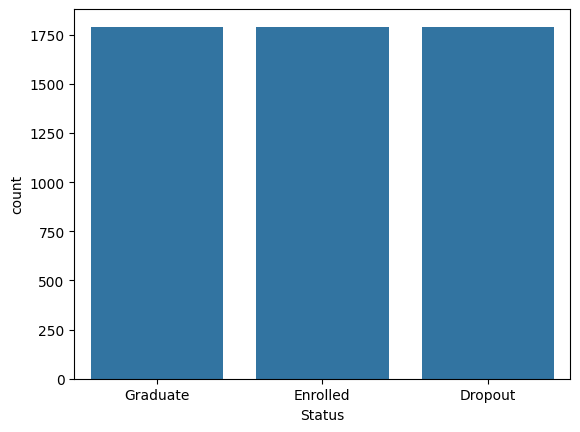

In [ ]:
df_majority_1 = train_df[(train_df.Status == "Graduate")]
df_majority_2 = train_df[(train_df.Status == "Dropout")]
df_minority = train_df[(train_df.Status == "Enrolled")]

df_majority_2_oversampled = resample(df_majority_2, n_samples=1791, random_state=42)
df_minority_oversampled = resample(df_minority, n_samples=1791, random_state=42)

oversampled_train_df = pd.concat([df_majority_1, df_majority_2_oversampled]).reset_index(drop=True)
oversampled_train_df = pd.concat([oversampled_train_df, df_minority_oversampled]).reset_index(drop=True)
oversampled_train_df = shuffle(oversampled_train_df, random_state=42)
oversampled_train_df.reset_index(drop=True, inplace=True)

oversampled_train_df[['Status']].value_counts()
sns.countplot(data=oversampled_train_df, x="Status")
plt.show()

## Encoding & Scaling

In [ ]:
label_encoder = LabelEncoder()

oversampled_train_df['Status'] = label_encoder.fit_transform(oversampled_train_df['Status'])
test_df['Status'] = label_encoder.transform(test_df['Status'])

joblib.dump(label_encoder, "label_encoder.joblib")

display(oversampled_train_df.head())
print('-'*200)
display(test_df.head())

,Tuition_fees_up_to_date,Course,Scholarship_holder,Application_mode,Debtor,Status,transform_Curricular_units_1st_sem_approved,transform_Curricular_units_2nd_sem_approved,transform_Curricular_units_2nd_sem_grade,transform_Curricular_units_2nd_sem_enrolled,transform_Curricular_units_2nd_sem_evaluations,transform_Curricular_units_1st_sem_grade,transform_Curricular_units_1st_sem_enrolled,transform_Age_at_enrollment,transform_Curricular_units_1st_sem_evaluations
0,yes,Social Service,yes,2nd phase - general contingent,no,2,0.484731,0.565695,0.847440,-0.095537,-0.243666,1.245508,-0.065206,-1.150201,-0.504255
1,yes,Veterinary Nursing,no,1st phase - general contingent,yes,1,0.184843,-0.052758,0.103841,-0.095537,2.180350,0.594183,-0.065206,0.370857,0.217520
2,yes,Basic Education,no,1st phase - general contingent,no,0,-1.712471,-1.591908,-1.902454,-0.095537,-2.140754,-2.074367,-0.065206,-0.635746,-0.504255
3,yes,Nursing,no,Change of course,no,1,-0.131080,0.565695,0.347670,0.357541,0.008058,0.524158,0.336258,0.103145,0.893260
4,yes,Management (evening attendance),no,Over 23 years old,no,1,-0.131080,-0.052758,0.259472,-0.552543,-0.243666,0.006379,-0.481488,1.248164,-0.017067


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,Tuition_fees_up_to_date,Course,Scholarship_holder,Application_mode,Debtor,Status,transform_Curricular_units_1st_sem_approved,transform_Curricular_units_2nd_sem_approved,transform_Curricular_units_2nd_sem_grade,transform_Curricular_units_2nd_sem_enrolled,transform_Curricular_units_2nd_sem_evaluations,transform_Curricular_units_1st_sem_grade,transform_Curricular_units_1st_sem_enrolled,transform_Age_at_enrollment,transform_Curricular_units_1st_sem_evaluations
1255,yes,Equinculture,yes,Over 23 years old,no,0,-1.712471,-1.138083,-0.243232,-0.095537,1.945330,-2.074367,-0.065206,1.392754,-0.257363
3458,yes,Social Service,no,2nd phase - general contingent,no,2,0.184843,0.565695,0.297121,-0.095537,0.008058,0.028071,-0.065206,-1.150201,0.217520
3390,yes,Basic Education,yes,2nd phase - general contingent,yes,2,0.771543,0.856244,0.334995,0.357541,-0.243666,0.388519,0.336258,-1.150201,-0.257363
1497,yes,Advertising and Marketing Management,no,2nd phase - general contingent,no,2,0.484731,0.263542,0.527718,-0.095537,0.008058,0.773865,-0.065206,-0.635746,-0.017067
1536,yes,Nursing,no,Over 23 years old,no,0,-1.712471,-1.591908,-1.902454,0.357541,1.471244,-2.074367,0.336258,1.157129,1.324791


In [ ]:
def scaling(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1,1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "scalers/scaler_{}.joblib".format(feature))

            X_test = np.asanyarray(df_test[feature])
            X_test = X_test.reshape(-1,1)
            df_test["{}".format(feature)] = scaler.transform(X_test)
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1,1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "scalers/scaler_{}.joblib".format(feature))
        return df

def one_hot_encoding(features, df, df_test=None):
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            encoder = OneHotEncoder(sparse_output=False, drop='first')
            encoder.fit(df[[feature]])

            # Dapatkan nama-nama kolom baru hasil One-Hot Encoding
            encoded_cols = encoder.get_feature_names_out([feature])

            # Tambahkan kolom hasil encoding ke DataFrame
            df[encoded_cols] = encoder.transform(df[[feature]])
            df_test[encoded_cols] = encoder.transform(df_test[[feature]])

            # Hapus kolom asli yang belum di-encode
            df.drop(columns=[feature], inplace=True)
            df_test.drop(columns=[feature], inplace=True)

            joblib.dump(encoder, "encoders/one_hot_encoder_{}.joblib".format(feature))
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            encoder = OneHotEncoder(sparse_output=False, drop='first')
            encoder.fit(df[[feature]])

            encoded_cols = encoder.get_feature_names_out([feature])
            df[encoded_cols] = encoder.transform(df[[feature]])
            df.drop(columns=[feature], inplace=True)

            joblib.dump(encoder, "encoders/one_hot_encoder_{}.joblib".format(feature))
        return df

In [ ]:
os.makedirs("scalers", exist_ok=True)
os.makedirs("encoders", exist_ok=True)

cols_to_encode = ['Tuition_fees_up_to_date', 'Application_mode', 'Course', 'Debtor', 'Scholarship_holder']

oversampled_train_df, test_df = scaling(numerical_columns, oversampled_train_df, test_df)
oversampled_train_df, test_df = one_hot_encoding(cols_to_encode, oversampled_train_df, test_df)

In [ ]:
oversampled_train_df.head(10)

,Status,transform_Curricular_units_1st_sem_approved,transform_Curricular_units_2nd_sem_approved,transform_Curricular_units_2nd_sem_grade,transform_Curricular_units_2nd_sem_enrolled,transform_Curricular_units_2nd_sem_evaluations,transform_Curricular_units_1st_sem_grade,transform_Curricular_units_1st_sem_enrolled,transform_Age_at_enrollment,transform_Curricular_units_1st_sem_evaluations,Tuition_fees_up_to_date_yes,Application_mode_1st phase - general contingent,Application_mode_1st phase - special contingent (Azores Island),Application_mode_1st phase - special contingent (Madeira Island),Application_mode_2nd phase - general contingent,Application_mode_3rd phase - general contingent,Application_mode_Change of course,Application_mode_Change of institution/course,Application_mode_Change of institution/course (International),Application_mode_Holders of other higher courses,Application_mode_International student (bachelor),"Application_mode_Ordinance No. 533-A/99, item b3 (Other Institution)",Application_mode_Ordinance No. 612/93,Application_mode_Ordinance No. 854-B/99,Application_mode_Over 23 years old,Application_mode_Short cycle diploma holders,Application_mode_Technological specialization diploma holders,Application_mode_Transfer,Course_Agronomy,Course_Animation and Multimedia Design,Course_Basic Education,Course_Biofuel Production Technologies,Course_Communication Design,Course_Equinculture,Course_Informatics Engineering,Course_Journalism and Communication,Course_Management,Course_Management (evening attendance),Course_Nursing,Course_Oral Hygiene,Course_Social Service,Course_Social Service (evening attendance),Course_Tourism,Course_Veterinary Nursing,Debtor_yes,Scholarship_holder_yes
0,2,0.324769,0.382418,0.668555,0.277680,0.238667,0.687981,0.305512,0.176411,0.188170,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.280442,0.272802,0.487771,0.277680,0.543625,0.553006,0.305512,0.586561,0.265760,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0,0.000000,0.000000,0.000000,0.277680,0.000000,0.000000,0.305512,0.315133,0.188170,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.233746,0.382418,0.547050,0.321912,0.270335,0.538495,0.347342,0.514373,0.338401,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0.233746,0.272802,0.525608,0.233064,0.238667,0.431195,0.262139,0.823124,0.240542,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2,0.367163,0.483680,0.635048,0.365811,0.270335,0.633034,0.347342,0.176411,0.214710,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,1,0.130244,0.272802,0.463097,0.233064,0.424314,0.431195,0.262139,0.514373,0.265760,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
7,1,0.324769,0.213569,0.613148,0.277680,0.206619,0.452348,0.305512,0.425539,0.188170,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,0.070447,0.150097,0.432886,0.233064,0.363480,0.463091,0.262139,0.922168,0.384790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,2,0.324769,0.382418,0.765136,0.277680,0.270335,0.740264,0.305512,0.514373,0.188170,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [ ]:
test_df.head(10)

,Status,transform_Curricular_units_1st_sem_approved,transform_Curricular_units_2nd_sem_approved,transform_Curricular_units_2nd_sem_grade,transform_Curricular_units_2nd_sem_enrolled,transform_Curricular_units_2nd_sem_evaluations,transform_Curricular_units_1st_sem_grade,transform_Curricular_units_1st_sem_enrolled,transform_Age_at_enrollment,transform_Curricular_units_1st_sem_evaluations,Tuition_fees_up_to_date_yes,Application_mode_1st phase - general contingent,Application_mode_1st phase - special contingent (Azores Island),Application_mode_1st phase - special contingent (Madeira Island),Application_mode_2nd phase - general contingent,Application_mode_3rd phase - general contingent,Application_mode_Change of course,Application_mode_Change of institution/course,Application_mode_Change of institution/course (International),Application_mode_Holders of other higher courses,Application_mode_International student (bachelor),"Application_mode_Ordinance No. 533-A/99, item b3 (Other Institution)",Application_mode_Ordinance No. 612/93,Application_mode_Ordinance No. 854-B/99,Application_mode_Over 23 years old,Application_mode_Short cycle diploma holders,Application_mode_Technological specialization diploma holders,Application_mode_Transfer,Course_Agronomy,Course_Animation and Multimedia Design,Course_Basic Education,Course_Biofuel Production Technologies,Course_Communication Design,Course_Equinculture,Course_Informatics Engineering,Course_Journalism and Communication,Course_Management,Course_Management (evening attendance),Course_Nursing,Course_Oral Hygiene,Course_Social Service,Course_Social Service (evening attendance),Course_Tourism,Course_Veterinary Nursing,Debtor_yes,Scholarship_holder_yes
1255,0,0.000000,0.080437,0.403390,0.277680,0.514057,0.000000,0.305512,0.862112,0.214710,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3458,2,0.280442,0.382418,0.534761,0.277680,0.270335,0.435690,0.305512,0.176411,0.265760,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3390,2,0.367163,0.433916,0.543969,0.321912,0.238667,0.510386,0.347342,0.176411,0.214710,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1497,2,0.324769,0.328864,0.590824,0.277680,0.270335,0.590242,0.305512,0.315133,0.240542,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1536,0,0.000000,0.000000,0.000000,0.321912,0.454414,0.000000,0.347342,0.798577,0.384790,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
287,2,0.233746,0.272802,0.494008,0.277680,0.394008,0.463091,0.305512,0.891145,0.265760,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3416,1,0.324769,0.382418,0.557883,0.277680,0.206619,0.473945,0.305512,0.315133,0.188170,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1366,0,0.447321,0.382418,0.650036,0.321912,0.301671,0.561528,0.427266,0.425539,0.338401,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3926,2,0.407936,0.483680,0.682388,0.365811,0.270335,0.625604,0.387866,0.315133,0.240542,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1055,2,0.367163,0.433916,0.705628,0.365811,0.301671,0.578959,0.347342,0.315133,0.214710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.

## PCA

In [ ]:
train_pca_df = oversampled_train_df.copy()
test_pca_df = test_df.copy()

In [ ]:
pca_columns = [item for item in numerical_columns if item != 'transform_Age_at_enrollment']
print(pca_columns)

['transform_Curricular_units_1st_sem_approved', 'transform_Curricular_units_2nd_sem_approved', 'transform_Curricular_units_2nd_sem_grade', 'transform_Curricular_units_2nd_sem_enrolled', 'transform_Curricular_units_2nd_sem_evaluations', 'transform_Curricular_units_1st_sem_grade', 'transform_Curricular_units_1st_sem_enrolled', 'transform_Curricular_units_1st_sem_evaluations']


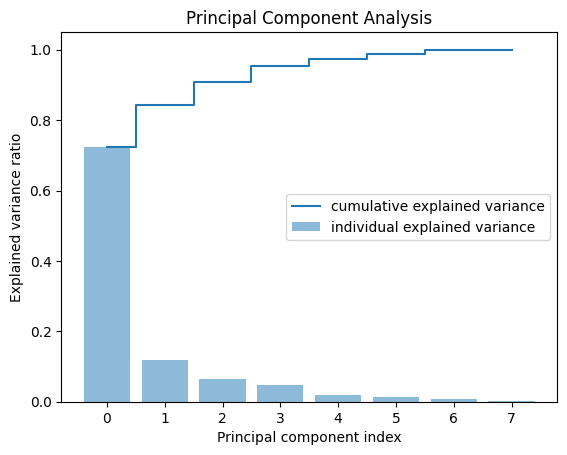

In [ ]:
pca = PCA(n_components=len(pca_columns), random_state=123)
pca.fit(train_pca_df[pca_columns])
princ_comp = pca.transform(train_pca_df[pca_columns])

var_exp = pca.explained_variance_ratio_.round(3)
cum_var_exp = np.cumsum(var_exp)

plt.bar(range(len(pca_columns)), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(len(pca_columns)), cum_var_exp, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Principal Component Analysis')
plt.legend(loc='best')
plt.show()

In [ ]:
# PCA on Train Dataset

pca = PCA(n_components=4, random_state=123)
pca.fit(train_pca_df[pca_columns])
joblib.dump(pca, "pca.joblib")
princ_comp = pca.transform(train_pca_df[pca_columns])
train_pca_df[["pc_1", "pc_2", "pc_3", "pc_4"]] = pd.DataFrame(princ_comp, columns=["pc_1", "pc_2", "pc_3", "pc_4"])
train_pca_df.drop(columns=pca_columns, axis=1, inplace=True)
train_pca_df.head()

,Status,transform_Age_at_enrollment,Tuition_fees_up_to_date_yes,Application_mode_1st phase - general contingent,Application_mode_1st phase - special contingent (Azores Island),Application_mode_1st phase - special contingent (Madeira Island),Application_mode_2nd phase - general contingent,Application_mode_3rd phase - general contingent,Application_mode_Change of course,Application_mode_Change of institution/course,Application_mode_Change of institution/course (International),Application_mode_Holders of other higher courses,Application_mode_International student (bachelor),"Application_mode_Ordinance No. 533-A/99, item b3 (Other Institution)",Application_mode_Ordinance No. 612/93,Application_mode_Ordinance No. 854-B/99,Application_mode_Over 23 years old,Application_mode_Short cycle diploma holders,Application_mode_Technological specialization diploma holders,Application_mode_Transfer,Course_Agronomy,Course_Animation and Multimedia Design,Course_Basic Education,Course_Biofuel Production Technologies,Course_Communication Design,Course_Equinculture,Course_Informatics Engineering,Course_Journalism and Communication,Course_Management,Course_Management (evening attendance),Course_Nursing,Course_Oral Hygiene,Course_Social Service,Course_Social Service (evening attendance),Course_Tourism,Course_Veterinary Nursing,Debtor_yes,Scholarship_holder_yes,pc_1,pc_2,pc_3,pc_4
0,2,0.176411,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.335119,-0.186424,-0.006043,0.091931
1,1,0.586561,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.179995,0.089021,-0.179013,-0.007164
2,0,0.315133,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.716433,0.083730,0.136487,0.012394
3,1,0.514373,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.204598,0.002392,-0.002620,0.012742
4,1,0.823124,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044229,-0.096260,-0.008309,-0.035311


In [ ]:
# PCA on Test Dataset

princ_comp_test = pca.transform(test_pca_df[pca_columns])
test_pca_df[["pc_1", "pc_2", "pc_3", "pc_4"]] = pd.DataFrame(princ_comp_test, columns=["pc_1", "pc_2", "pc_3", "pc_4"], index=test_pca_df.index)
test_pca_df.drop(columns=pca_columns, axis=1, inplace=True)
test_pca_df.head()

,Status,transform_Age_at_enrollment,Tuition_fees_up_to_date_yes,Application_mode_1st phase - general contingent,Application_mode_1st phase - special contingent (Azores Island),Application_mode_1st phase - special contingent (Madeira Island),Application_mode_2nd phase - general contingent,Application_mode_3rd phase - general contingent,Application_mode_Change of course,Application_mode_Change of institution/course,Application_mode_Change of institution/course (International),Application_mode_Holders of other higher courses,Application_mode_International student (bachelor),"Application_mode_Ordinance No. 533-A/99, item b3 (Other Institution)",Application_mode_Ordinance No. 612/93,Application_mode_Ordinance No. 854-B/99,Application_mode_Over 23 years old,Application_mode_Short cycle diploma holders,Application_mode_Technological specialization diploma holders,Application_mode_Transfer,Course_Agronomy,Course_Animation and Multimedia Design,Course_Basic Education,Course_Biofuel Production Technologies,Course_Communication Design,Course_Equinculture,Course_Informatics Engineering,Course_Journalism and Communication,Course_Management,Course_Management (evening attendance),Course_Nursing,Course_Oral Hygiene,Course_Social Service,Course_Social Service (evening attendance),Course_Tourism,Course_Veterinary Nursing,Debtor_yes,Scholarship_holder_yes,pc_1,pc_2,pc_3,pc_4
1255,0,0.862112,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.327884,0.167872,-0.082246,-0.385234
3458,2,0.176411,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.137674,-0.028878,0.059786,-0.034671
3390,2,0.176411,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.228266,-0.038156,0.128641,0.057273
1497,2,0.315133,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.234922,-0.094927,-0.020684,0.055986
1536,0,0.798577,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.572546,0.418852,-0.118521,-0.146788


# Modelling

In [ ]:
X_train = train_pca_df.drop(columns=['Status'], errors='ignore')
y_train = train_pca_df['Status']

X_test = test_pca_df.drop(columns=['Status'], errors='ignore')
y_test = test_pca_df['Status']

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test setelah diselaraskan:", X_test.shape)

Ukuran X_train: (5373, 41)
Ukuran X_test setelah diselaraskan: (885, 41)


## Baseline

In [ ]:
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Random Forest (Hyperparameter Tuning)

In [ ]:
# Definisikan model yang akan di-tune
rf_model = RandomForestClassifier(random_state=42)

# Tentukan ruang pencarian hyperparameter
search_space = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(5, 30),
    'min_samples_split': Integer(2, 10),
    'criterion': Categorical(['gini', 'entropy'])
}

# Inisialisasi BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf_model,
    search_spaces=search_space,
    n_iter=25,  # Jumlah total iterasi
    cv=4,
    n_jobs=-1,
    random_state=42,
    scoring='accuracy'
)

# Definisikan callback untuk menampilkan progress/log iterasi
# n_total adalah jumlah total iterasi (n_iter)
verbose_callback = VerboseCallback(n_total=25)

# Jalankan proses fitting dengan menyertakan callback
print("Memulai optimasi bayesian dengan progress tracking...")
bayes_search.fit(X_train, y_train, callback=[verbose_callback])

# Menampilkan parameter terbaik hasil optimasi
print("\nHyperparameter Terbaik:", bayes_search.best_params_)
print("Akurasi Terbaik (CV):", bayes_search.best_score_)

Iteration No: 1 started. Searching for the next optimal point.
Memulai optimasi bayesian dengan progress tracking...
Iteration No: 1 ended. Search finished for the next optimal point.
Time taken: 8.5067
Function value obtained: -0.8731
Current minimum: -0.8731
Iteration No: 2 started. Searching for the next optimal point.
Iteration No: 2 ended. Search finished for the next optimal point.
Time taken: 13.7709
Function value obtained: -0.9034
Current minimum: -0.9034
Iteration No: 3 started. Searching for the next optimal point.
Iteration No: 3 ended. Search finished for the next optimal point.
Time taken: 5.2961
Function value obtained: -0.9027
Current minimum: -0.9034
Iteration No: 4 started. Searching for the next optimal point.
Iteration No: 4 ended. Search finished for the next optimal point.
Time taken: 4.3621
Function value obtained: -0.7862
Current minimum: -0.9034
Iteration No: 5 started. Searching for the next optimal point.
Iteration No: 5 ended. Search finished for the next op

# Evaluation

## Baseline

In [ ]:
dt_baseline_pred = dt_baseline.predict(X_test)

print('Baseline Decision Tree Accuracy: ' + str(accuracy_score(y_test, dt_baseline_pred)))
print('-'*50)
print('Baseline Decision Tree Confusion Matrix:')
print(confusion_matrix(y_test, dt_baseline_pred))
print('-'*50)
print('Baseline Decision Tree Classification Report:')
print(classification_report(y_test, dt_baseline_pred, target_names=label_encoder.classes_))

Baseline Decision Tree Accuracy: 0.6418079096045197
--------------------------------------------------
Baseline Decision Tree Confusion Matrix:
[[197  71  48]
 [ 45  48  58]
 [ 35  60 323]]
--------------------------------------------------
Baseline Decision Tree Classification Report:
              precision    recall  f1-score   support

     Dropout       0.71      0.62      0.66       316
    Enrolled       0.27      0.32      0.29       151
    Graduate       0.75      0.77      0.76       418

    accuracy                           0.64       885
   macro avg       0.58      0.57      0.57       885
weighted avg       0.66      0.64      0.65       885



## Random Forest

In [ ]:
rf_pred = rf.predict(X_test)

print('Random Forest Accuracy: ' + str(accuracy_score(y_test, rf_pred)))
print('-'*50)
print('Random Forest Confusion Matrix:')
print(confusion_matrix(y_test, rf_pred))
print('-'*50)
print('Random Forest Classification Report:')
print(classification_report(y_test, rf_pred, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.7299435028248588
--------------------------------------------------
Random Forest Confusion Matrix:
[[219  45  52]
 [ 41  56  54]
 [ 13  34 371]]
--------------------------------------------------
Random Forest Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.69      0.74       316
    Enrolled       0.41      0.37      0.39       151
    Graduate       0.78      0.89      0.83       418

    accuracy                           0.73       885
   macro avg       0.66      0.65      0.65       885
weighted avg       0.72      0.73      0.72       885



## Random Forest (Bayesian Optimization)

In [ ]:
# Gunakan model terbaik untuk melakukan prediksi
best_rf_model = bayes_search.best_estimator_
rf_opt_pred = best_rf_model.predict(X_test)

print('Random Forest (Tuned) Accuracy: ' + str(accuracy_score(y_test, rf_opt_pred)))
print('-'*50)
print('Random Forest (Tuned) Confusion Matrix:')
print(confusion_matrix(y_test, rf_opt_pred))
print('-'*50)
print('Classification Report:')
print(classification_report(y_test, rf_opt_pred, target_names=label_encoder.classes_))

Random Forest (Tuned) Accuracy: 0.7265536723163842
--------------------------------------------------
Random Forest (Tuned) Confusion Matrix:
[[216  52  48]
 [ 42  56  53]
 [ 12  35 371]]
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.68      0.74       316
    Enrolled       0.39      0.37      0.38       151
    Graduate       0.79      0.89      0.83       418

    accuracy                           0.73       885
   macro avg       0.66      0.65      0.65       885
weighted avg       0.72      0.73      0.72       885



In [ ]:
# Save best model

joblib.dump(rf, "best_rf_model.joblib")

['best_rf_model.joblib']